In [26]:
import os
import sys
import darkfield
import numpy as np
from bash_config import write_bash
from darkfield.diffra_v2 import HOME 

In [33]:
################## DEFINING THE BASH PARAMETERS OF THE SIMULATION ################

upd_params = {
    'n_cpus': 24,
    'mem': '600GB',
    'yaml': 'LP_267.yaml'
} #previously n_cpus=24, mem=650
path = os.path.join(HOME,'bash')
bash_path = write_bash(path, 500, upd_params)
print(bash_path)


/home/yu79deg/darkfield_p5438/bash/job.slurm


In [34]:
#################### LAUNCHING THE SIMULATION #################
os.system(f"sbatch {bash_path}")

Submitted batch job 3896215


0

In [36]:
#################### VISUALIZING THE QUEUE #################
!squeue --me

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
           3895923   hij-gpu jupyterl  yu79deg  R    2:19:47      1 gpu001


In [ ]:
!scancel 3858279

/home/yu79deg
[1e-11, 50]
 This is outside (-1.01e+02,-9.50e+02):start
 This is outside (-1.00e+02,-9.00e+02):beam_shaper


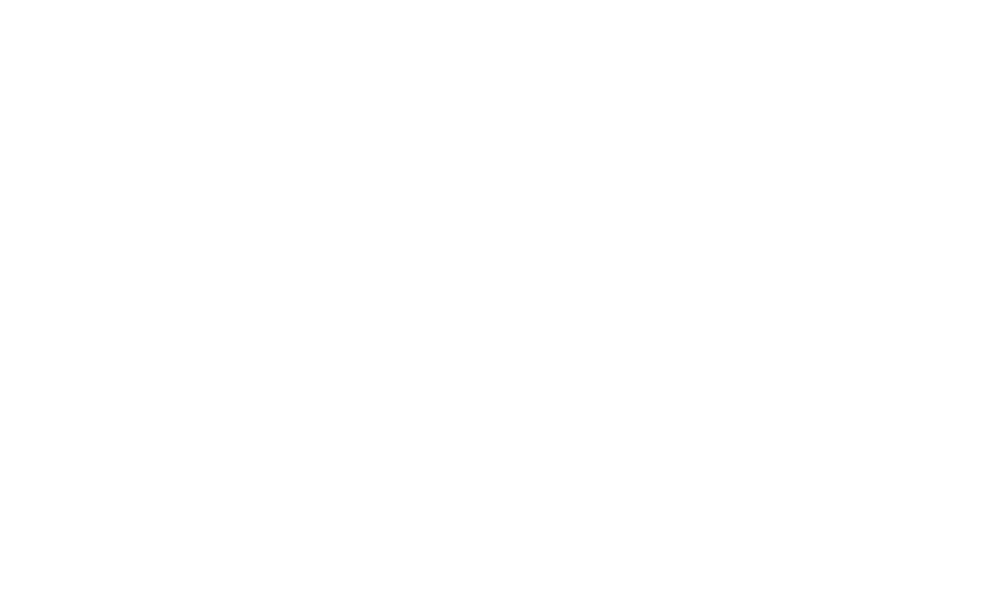

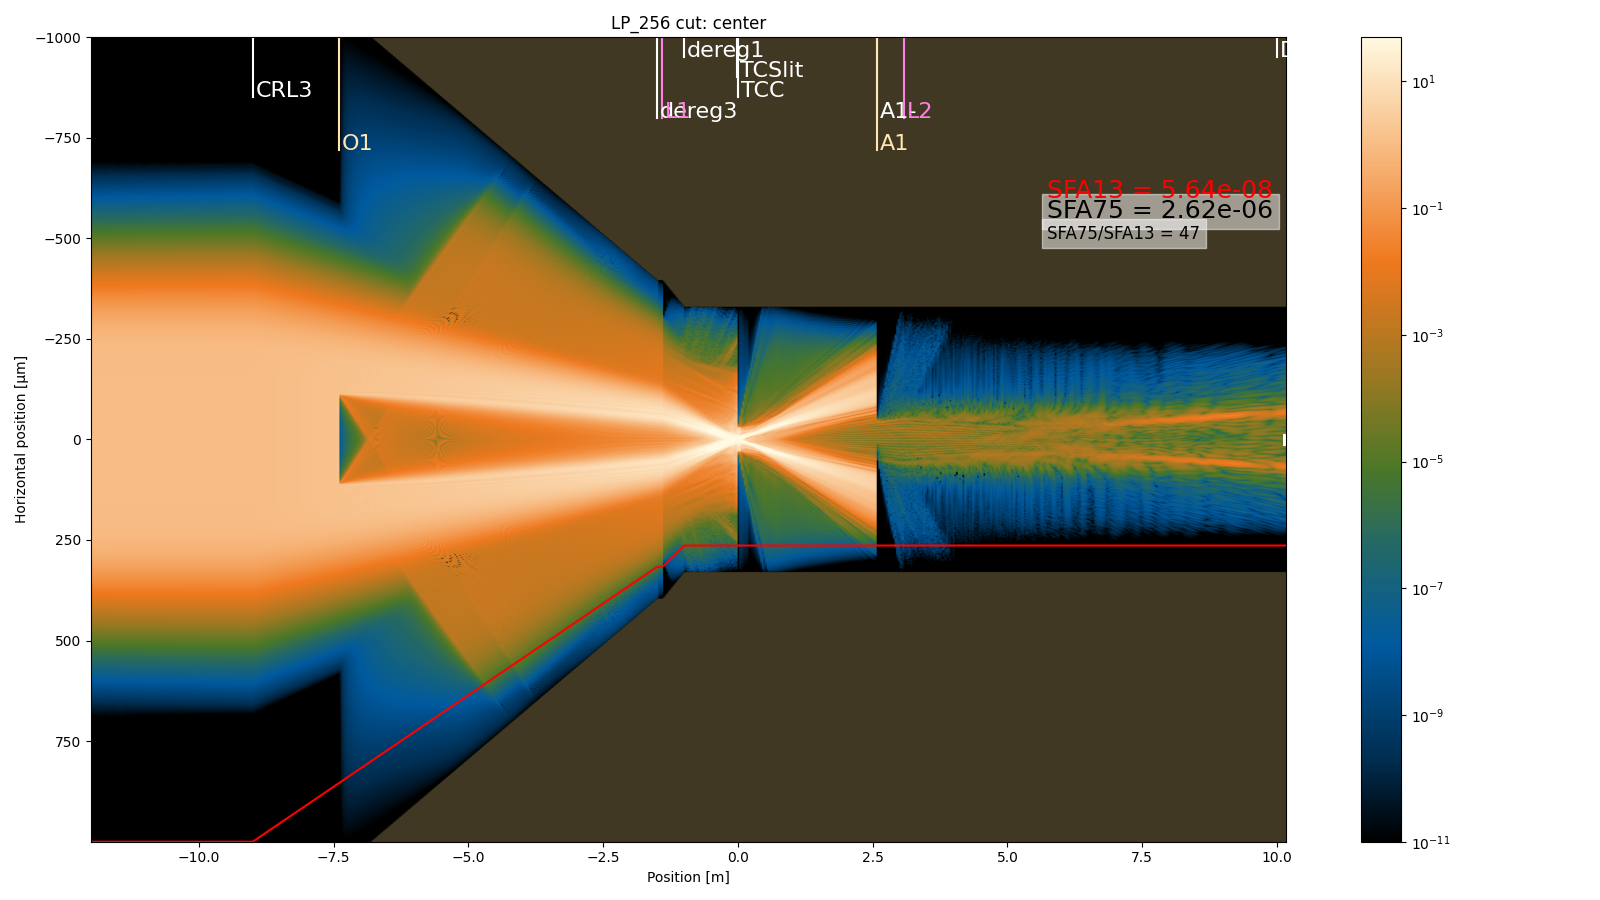

In [62]:
##################### FLOW PLOT OF SIMULATIONS ####################
###################################################################

#from darkfield.diffra_v2 import flow_plot
import importlib
import darkfield.diffra_v2
importlib.reload(darkfield.diffra_v2)
from darkfield.diffra_v2 import flow_plot

#%matplotlib widget

#Going back to the root folder :
%cd /home/yu79deg 

project_dir = "darkfield_p5438/Aime"
#project_dir="/home/yu79deg/darkfield_p5438/Aime"

file = "LP_256" #name of the file
#file = "Matt_2" #name of the file

############# PLOTTING PARAMETERS ############
cl = [1e-11, 50] #Color scale (min, max) for the pcolor()
gyax_def = [-1000, 1000, 0.1] #vertical axis (start, end, stepsize) (in [um])
vertical_type = 'center' #(center, integral, vert-integral)
log = 1 #log or linear scale (LINEAR SCALE DOESNT WORK)
xl = [-15,15] #horizontal axis limits
xl = None #horizontal axis limits
flow_plot_crange = 1e-5 #relative scale to plot images.

#==================================================#
flow_figs = 0 #save the flow figs (Pretty long to run!)
create_video_ff = 0 #create a video from the saved pictures
#==================================================#

# Call the function
flow_plot(project_dir, file, cl=cl, gyax_def=gyax_def,
          vertical_type=vertical_type, log=log, xl=xl,
          flow_figs=flow_figs, flow_plot_crange=flow_plot_crange)



if create_video_ff and flow_figs:
    image_dir = f"darkfield_p5438/Aime/flow_figs/{file}"
    output_file = "movie.mp4"
    framerate = 10
    video_images_path = ""
    input_pattern = f"{image_dir}/ff_%04d.png"
    !ffmpeg -framerate {framerate} -i "{input_pattern}" -c:v libx264 -pix_fmt yuv420p "{image_dir}/{output_file}"

In [54]:
######################### GENERATE YAML FILES FOR SCANS ###############

!python /home/yu79deg/darkfield_p5438/yamls/yaml_scan_Div.py

Written LP_278.yaml (wide_factor=0.4)
Written LP_279.yaml (wide_factor=0.5)
Written LP_280.yaml (wide_factor=0.6)
Written LP_281.yaml (wide_factor=0.7)
Written LP_282.yaml (wide_factor=0.8)
Written LP_283.yaml (wide_factor=0.9)
Written LP_284.yaml (wide_factor=1)
Written LP_285.yaml (wide_factor=1.2)
Written LP_286.yaml (wide_factor=1.4)


In [55]:
######################## RUN ALL THE SIMULATIONS ###################

def get_simulation_list(manual_list=None, start=None, end=None):
    if manual_list:
        return manual_list
    elif start is not None and end is not None:
        return [f"LP_{i}" for i in range(start, end + 1)]
    else:
        raise ValueError("Either provide a manual list or a start and end value.")

###################### Option 1: manual list #######################
#sim_names = get_simulation_list(manual_list=["LP_30", "LP_31", "LP_35"])

#################### Option 2: auto-generated list #################
sim_names = get_simulation_list(start=278, end=286)

################### Parameters for SLURM submission ################
upd_params = {
    'n_cpus': 24,
    'mem': '600GB',
}

# Folder for bash scripts
path = os.path.join(HOME, 'bash')

#################### Loop over all simulation names ################
for sim in sim_names:
    upd_params['yaml'] = sim + '.yaml'  # Assign current yaml file
    bash_path = write_bash(path, 6000, upd_params)
    print(f"Submitting {sim} with bash file: {bash_path}")
    os.system(f"sbatch {bash_path}")


!squeue --me # See that all simulations are indeed running.


Submitting LP_278 with bash file: /home/yu79deg/darkfield_p5438/bash/job.slurm
Submitted batch job 3883748
Submitting LP_279 with bash file: /home/yu79deg/darkfield_p5438/bash/job.slurm
Submitted batch job 3883749
Submitting LP_280 with bash file: /home/yu79deg/darkfield_p5438/bash/job.slurm
Submitted batch job 3883750
Submitting LP_281 with bash file: /home/yu79deg/darkfield_p5438/bash/job.slurm
Submitted batch job 3883751
Submitting LP_282 with bash file: /home/yu79deg/darkfield_p5438/bash/job.slurm
Submitted batch job 3883752
Submitting LP_283 with bash file: /home/yu79deg/darkfield_p5438/bash/job.slurm
Submitted batch job 3883753
Submitting LP_284 with bash file: /home/yu79deg/darkfield_p5438/bash/job.slurm
Submitted batch job 3883754
Submitting LP_285 with bash file: /home/yu79deg/darkfield_p5438/bash/job.slurm
Submitted batch job 3883755
Submitting LP_286 with bash file: /home/yu79deg/darkfield_p5438/bash/job.slurm
Submitted batch job 3883756
             JOBID PARTITION     NAME

In [59]:
!squeue --me # See that all simulations are indeed running.

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
           3883736   hij-gpu   LP_270  yu79deg PD       0:00      1 (Resources)
           3883737   hij-gpu   LP_271  yu79deg PD       0:00      1 (Priority)
           3883738   hij-gpu   LP_272  yu79deg PD       0:00      1 (Priority)
           3883739   hij-gpu   LP_273  yu79deg PD       0:00      1 (Priority)
           3883740   hij-gpu   LP_274  yu79deg PD       0:00      1 (Priority)
           3883741   hij-gpu   LP_275  yu79deg PD       0:00      1 (Priority)
           3883742   hij-gpu   LP_276  yu79deg PD       0:00      1 (Priority)
           3883748   hij-gpu   LP_278  yu79deg PD       0:00      1 (Priority)
           3883749   hij-gpu   LP_279  yu79deg PD       0:00      1 (Priority)
           3883750   hij-gpu   LP_280  yu79deg PD       0:00      1 (Priority)
           3883751   hij-gpu   LP_281  yu79deg PD       0:00      1 (Priority)
           3883752   hij-gpu   LP_282  yu79de

In [ ]:
#################### EXTRACT SHADOW FACTOR FROM SIMULATION ###################
import darkfield.mmmUtils_v2 as mu

project_dir = '/home/yu79deg/darkfield_p5438/Aime'
yaml_tag = 'LP_124'  # Simulation name


pickle_file = os.path.join(project_dir, 'pickles', f'{yaml_tag}_res.pickle')
print(f"Loading: {pickle_file}")


res = mu.loadPickle(pickle_file) #loading the general parameters
params=res[1]

SF_13 = params['intensities']['roi'] / params['intensities']['TCC']
SF_75 = params['intensities']['roi2'] / params['intensities']['TCC']

print(SF_13,SF_75)


Processing simulation: LP_242

Processing simulation: LP_243

Processing simulation: LP_244

Processing simulation: LP_245

Processing simulation: LP_246

Processing simulation: LP_247

Processing simulation: LP_248

Processing simulation: LP_249


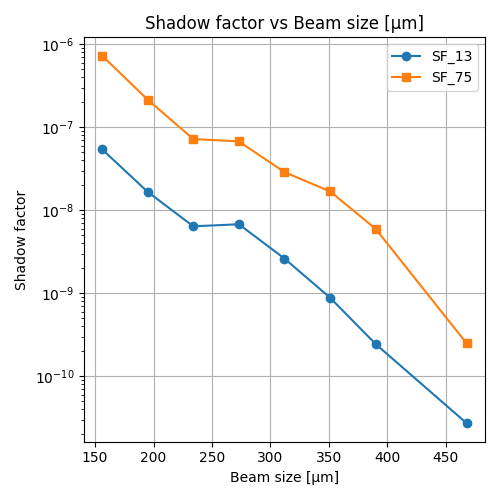

In [40]:
################## PLOT THE EVOLUTION OF SHADOW FACTOR AS A FUNCTION OF A GIVEN SCANNED PARAMETER ###############

import os
import yaml
import numpy as np
import matplotlib.pyplot as plt
import darkfield.mmmUtils_v2 as mu  # This must be available in your environment

%matplotlib widget

# Setup paths
project_dir = '/home/yu79deg/darkfield_p5438/Aime'
yaml_dir = '/home/yu79deg/darkfield_p5438/yamls'
pickle_dir = os.path.join(project_dir, 'pickles')

# List of simulations (numbers only)
simulation_ids = np.arange(242,250)
simulations = [f'LP_{i}' for i in simulation_ids]

# Parameter config
ph_key = 'beam_shaper'               # The element key in YAML
scan_param_name = 'size'    # Parameter to scan
xaxis_label = 'Beam size [µm]'  # Label for plot

# Data lists
scanned_values = []
sf_13_list = []
sf_75_list = []

# Loop through simulations
for sim in simulations:
    print(f"\nProcessing simulation: {sim}")

    # --- Load pickle file ---
    pickle_file = os.path.join(pickle_dir, f'{sim}_res.pickle')
    if not os.path.isfile(pickle_file):
        print(f"⚠️ Missing pickle file: {pickle_file}")
        continue

    res = mu.loadPickle(pickle_file)
    params = res[1]

    try:
        sf_13 = params['intensities']['roi'] / params['intensities']['TCC']
        sf_75 = params['intensities']['roi2'] / params['intensities']['TCC']
    except KeyError:
        print(f"⚠️ Missing intensity data in: {sim}")
        continue

    # --- Load YAML file ---
    yaml_file = os.path.join(yaml_dir, f'{sim}.yaml')
    if not os.path.isfile(yaml_file):
        print(f"⚠️ Missing YAML file: {yaml_file}")
        continue

    with open(yaml_file, 'r') as f:
        yaml_data = yaml.safe_load(f)

    # --- Extract parameter ---
    try:
        scan_value = yaml_data[ph_key][scan_param_name]
    except KeyError:
        print(f"⚠️ Parameter '{scan_param_name}' not found in element '{ph_key}' for {sim}")
        continue

    # Store data (convert to µm)
    scanned_values.append(scan_value * 1e6)
    sf_13_list.append(sf_13)
    sf_75_list.append(sf_75)

# --- Plotting ---
plt.figure(figsize=(5, 5))
plt.plot(scanned_values, sf_13_list, 'o-', label='SF_13')
plt.plot(scanned_values, sf_75_list, 's-', label='SF_75')
plt. yscale("log")
plt.xlabel(xaxis_label)
plt.ylabel("Shadow factor")
plt.title(f"Shadow factor vs {xaxis_label}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



========== Processing LP_278 ==========

[1e-11, 50]
 This is outside (-1.01e+02,-5.70e+02):start
 This is outside (-1.00e+02,-5.40e+02):beam_shaper

========== Processing LP_279 ==========

[1e-11, 50]
 This is outside (-1.01e+02,-5.70e+02):start
 This is outside (-1.00e+02,-5.40e+02):beam_shaper

========== Processing LP_280 ==========

[1e-11, 50]
 This is outside (-1.01e+02,-5.70e+02):start
 This is outside (-1.00e+02,-5.40e+02):beam_shaper

========== Processing LP_281 ==========

[1e-11, 50]
 This is outside (-1.01e+02,-5.70e+02):start
 This is outside (-1.00e+02,-5.40e+02):beam_shaper

========== Processing LP_282 ==========

[1e-11, 50]
 This is outside (-1.01e+02,-5.70e+02):start
 This is outside (-1.00e+02,-5.40e+02):beam_shaper

========== Processing LP_283 ==========

[1e-11, 50]
 This is outside (-1.01e+02,-5.70e+02):start
 This is outside (-1.00e+02,-5.40e+02):beam_shaper

========== Processing LP_284 ==========

[1e-11, 50]
 This is outside (-1.01e+02,-5.70e+02):start
 

<Figure size 1000x600 with 0 Axes>

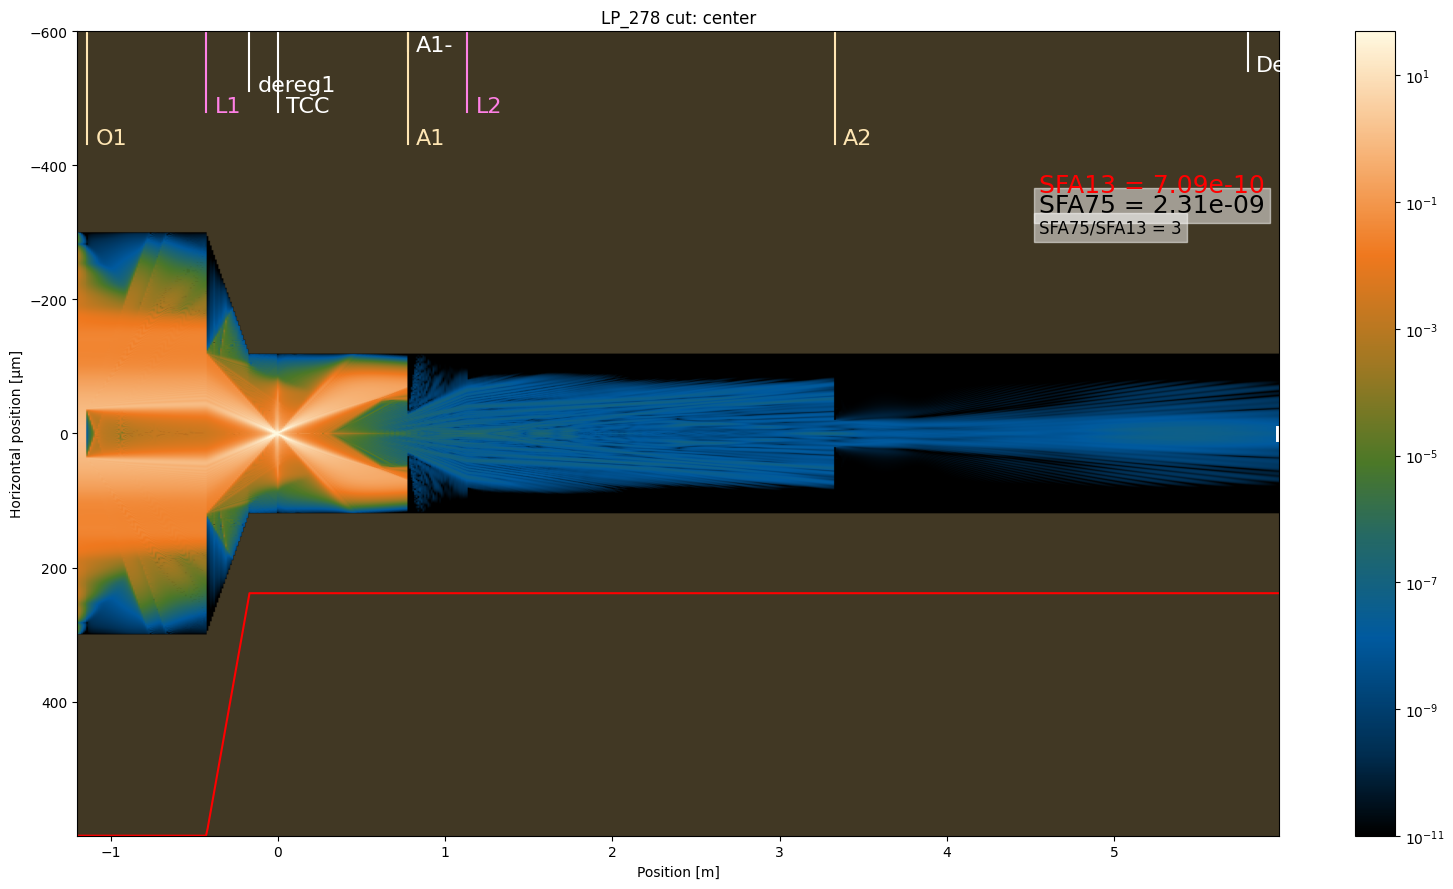

<Figure size 1000x600 with 0 Axes>

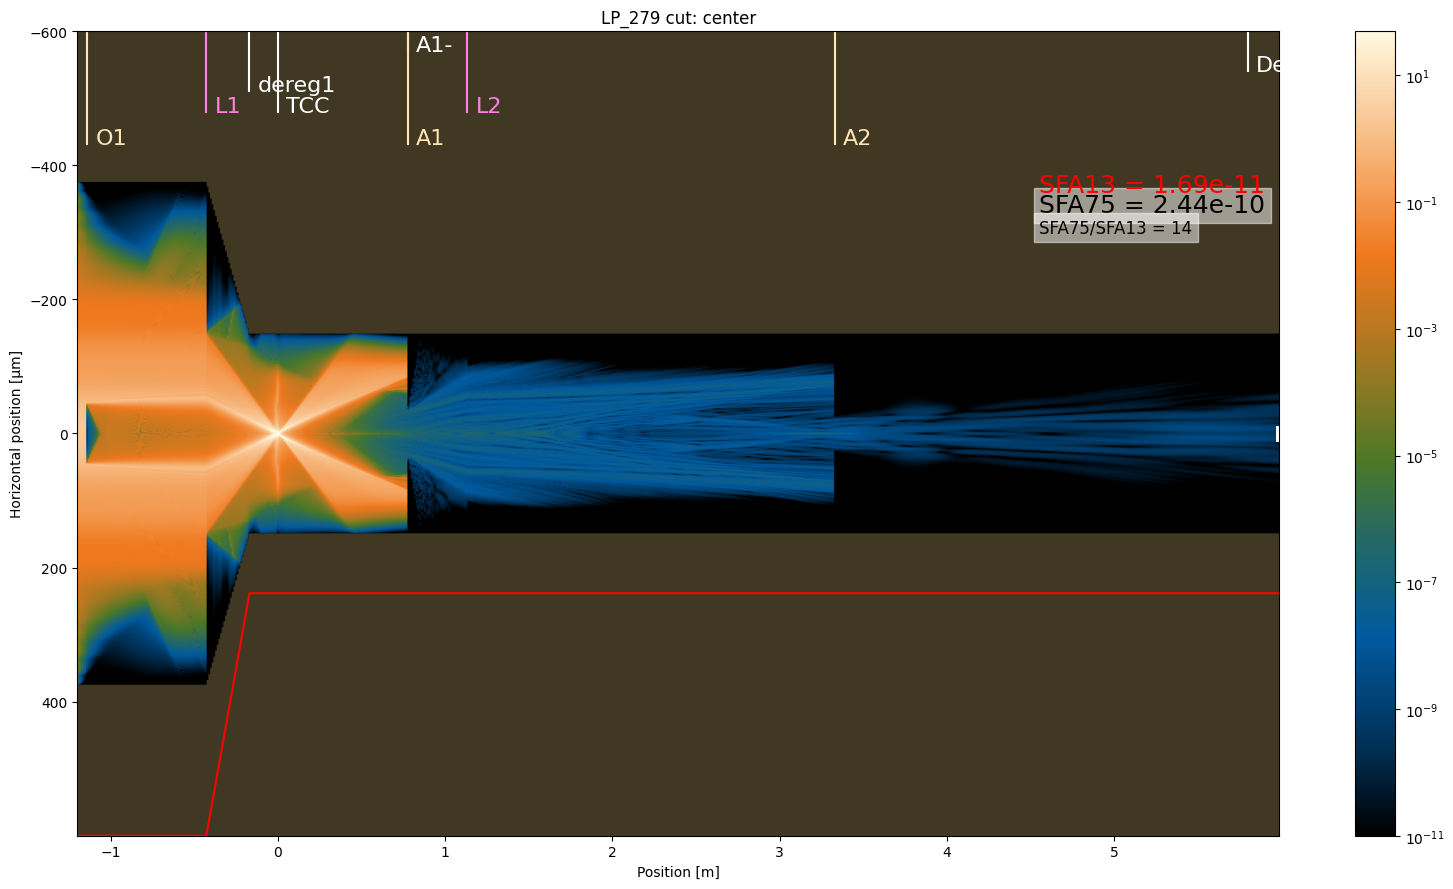

<Figure size 1000x600 with 0 Axes>

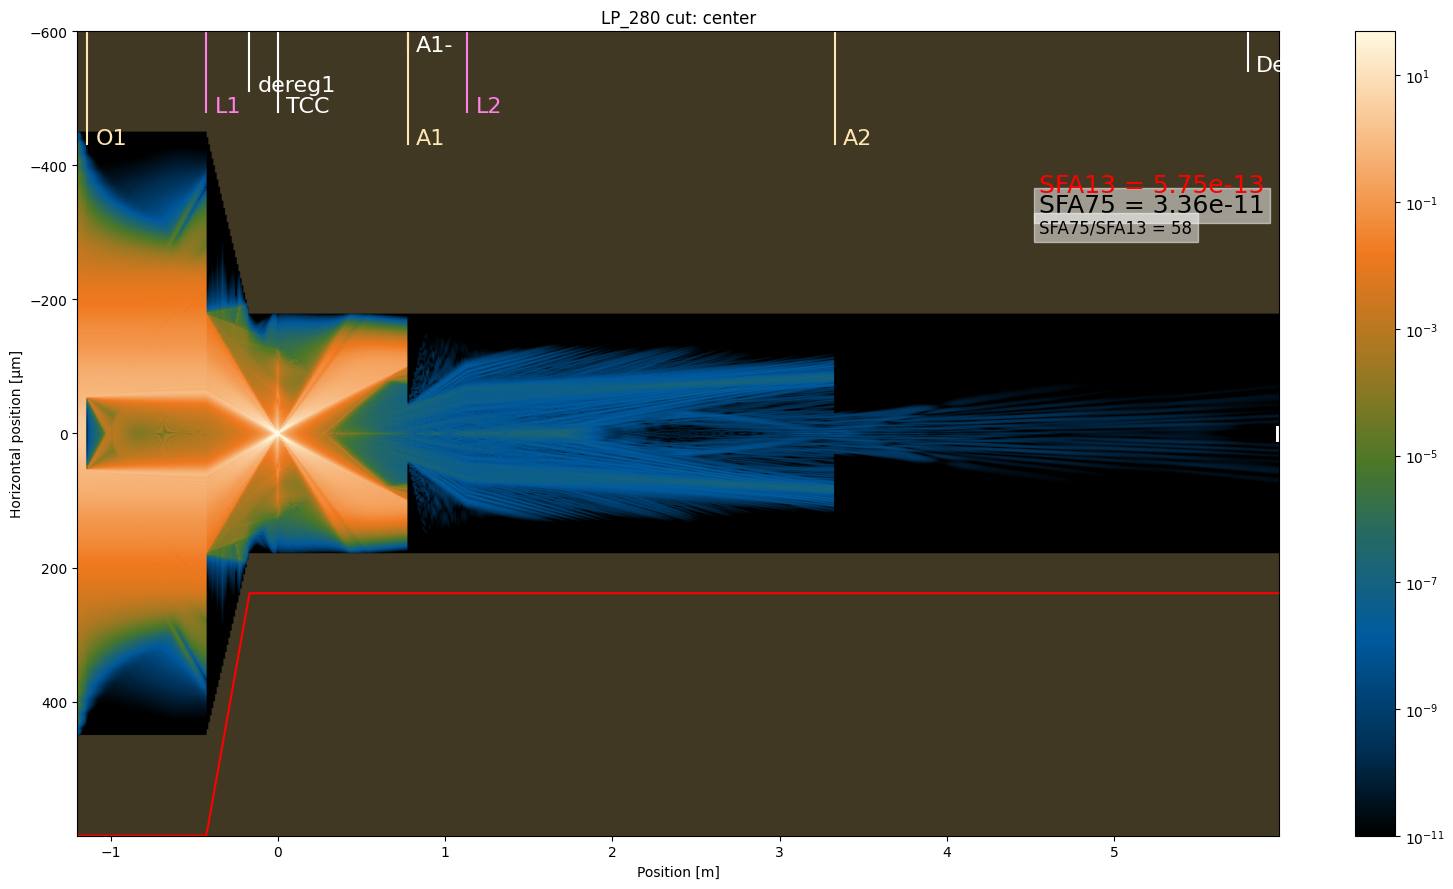

<Figure size 1000x600 with 0 Axes>

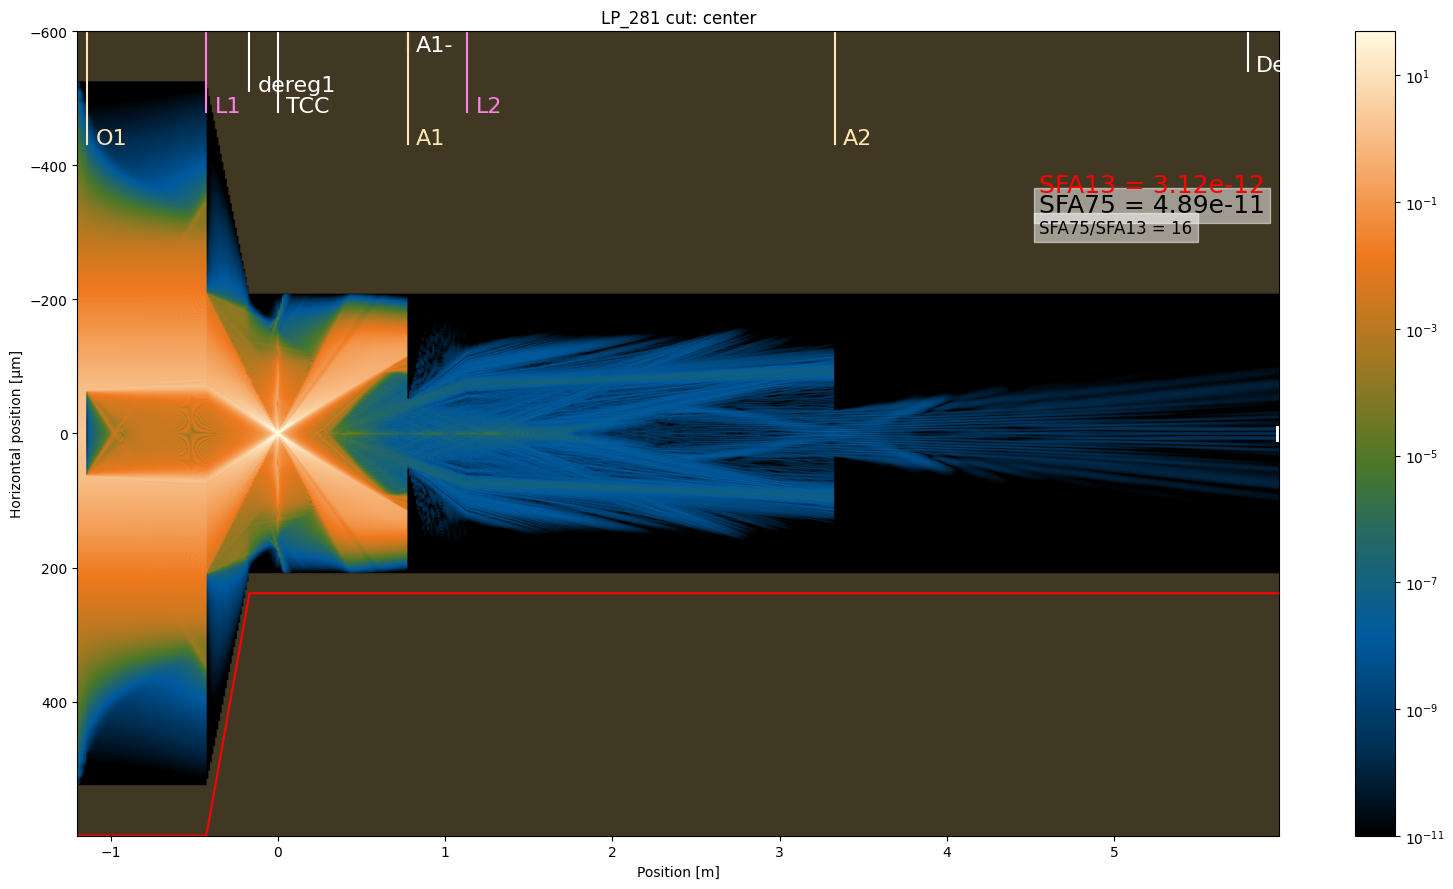

<Figure size 1000x600 with 0 Axes>

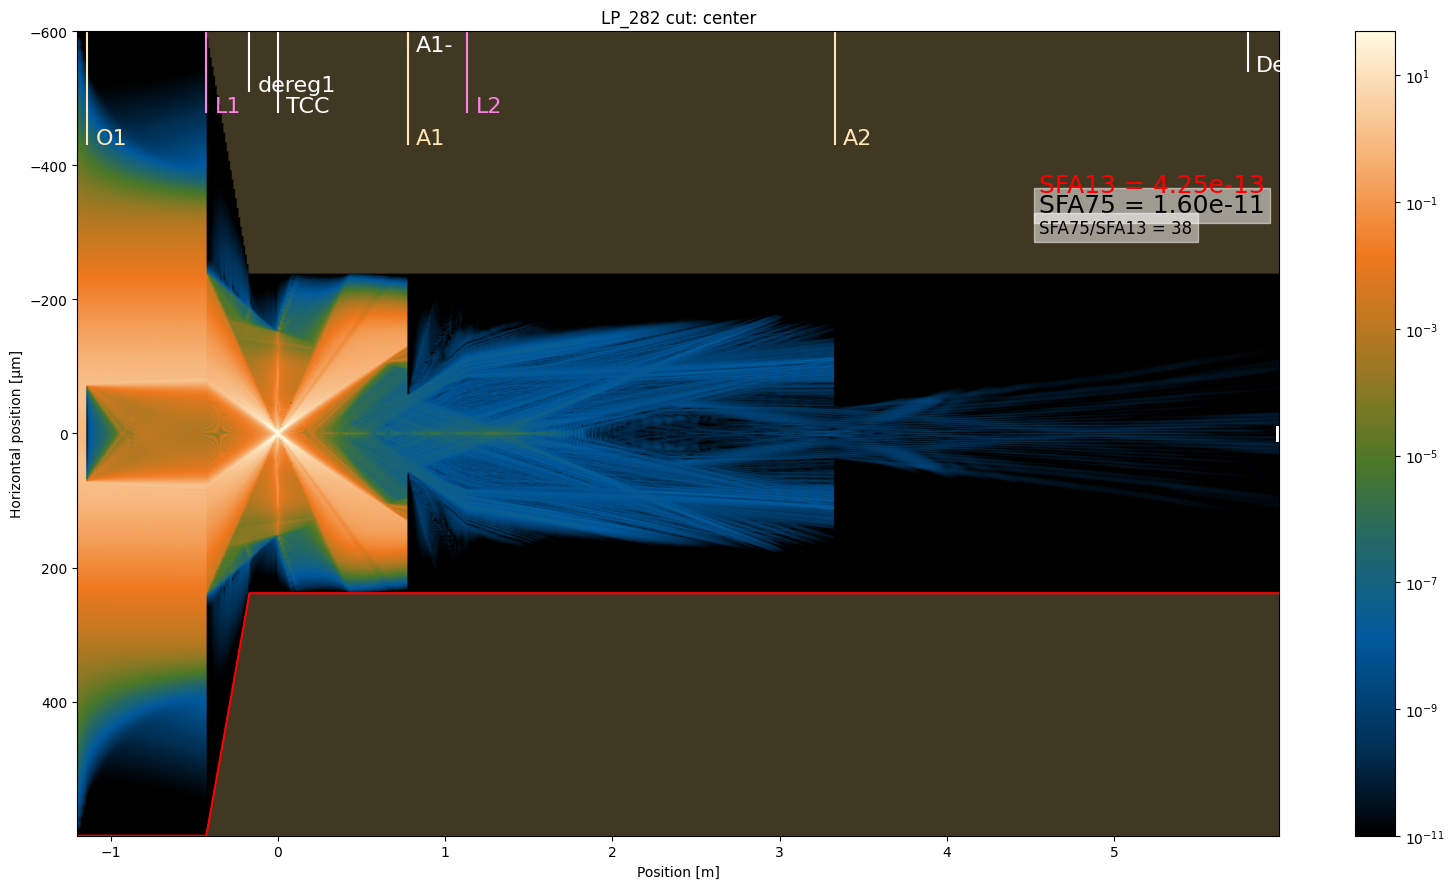

<Figure size 1000x600 with 0 Axes>

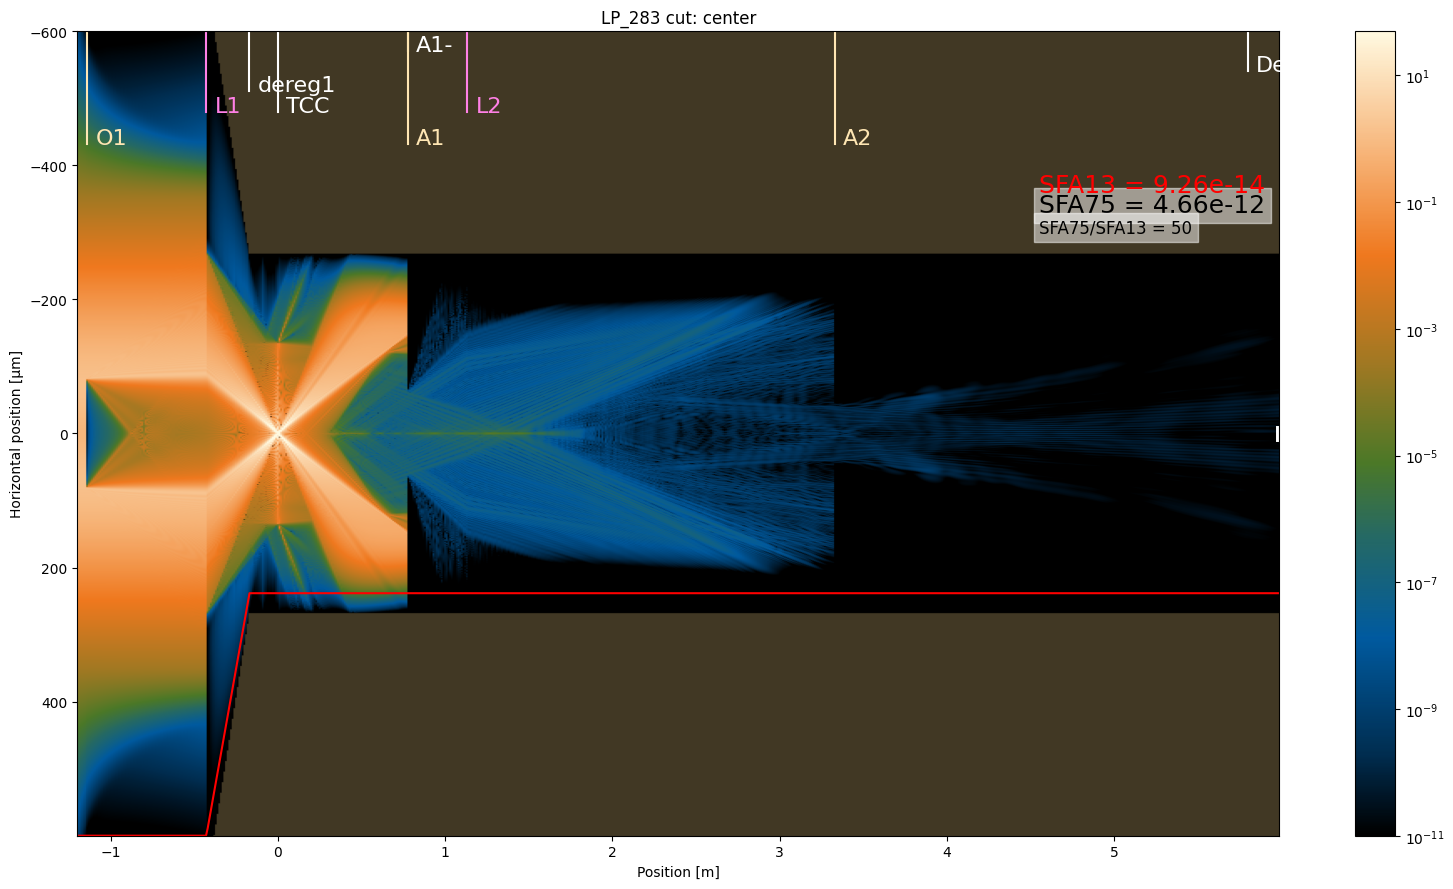

<Figure size 1000x600 with 0 Axes>

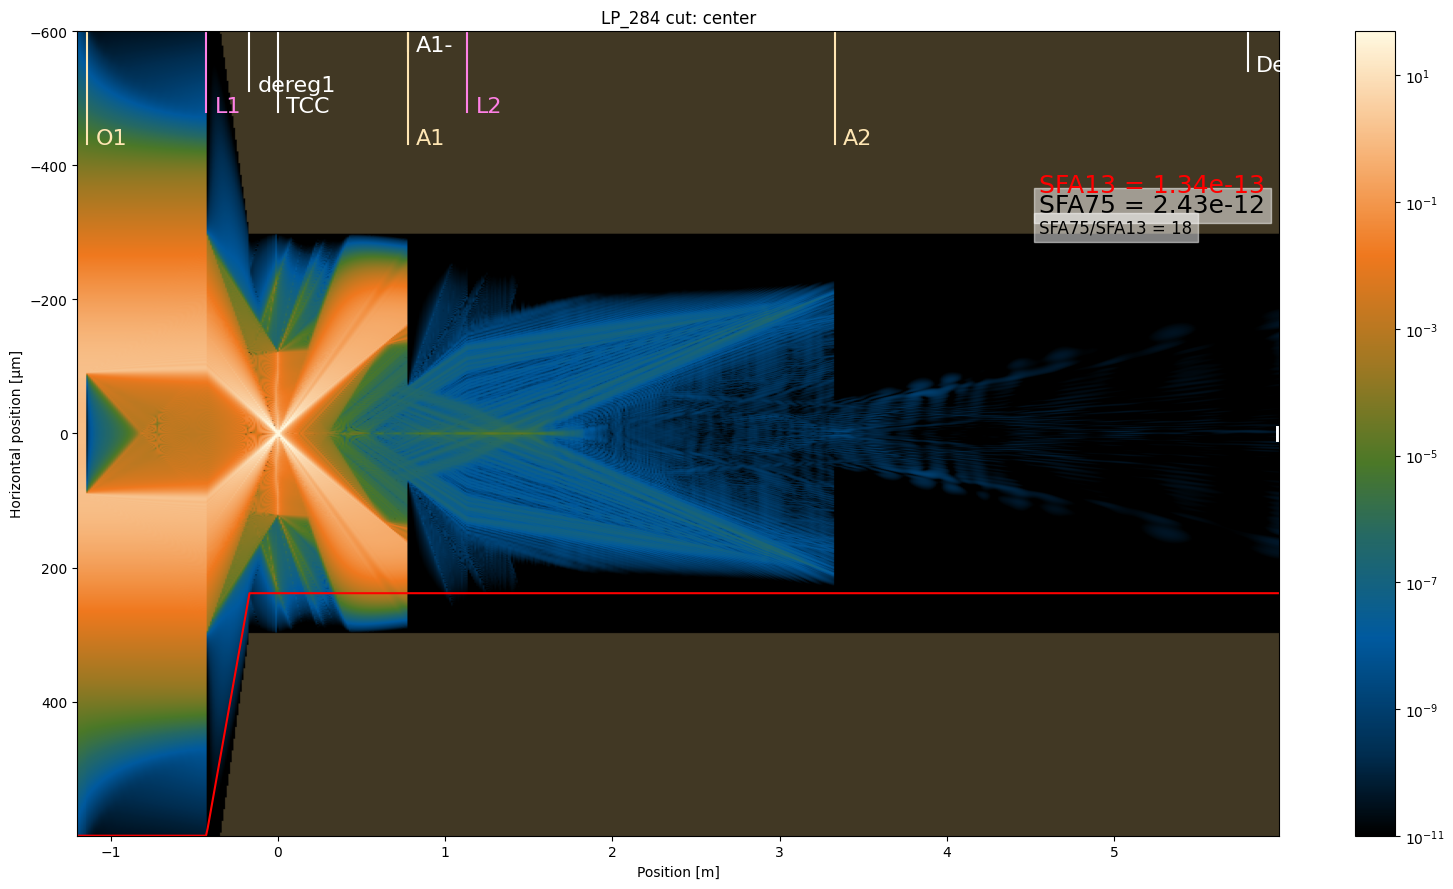

<Figure size 1000x600 with 0 Axes>

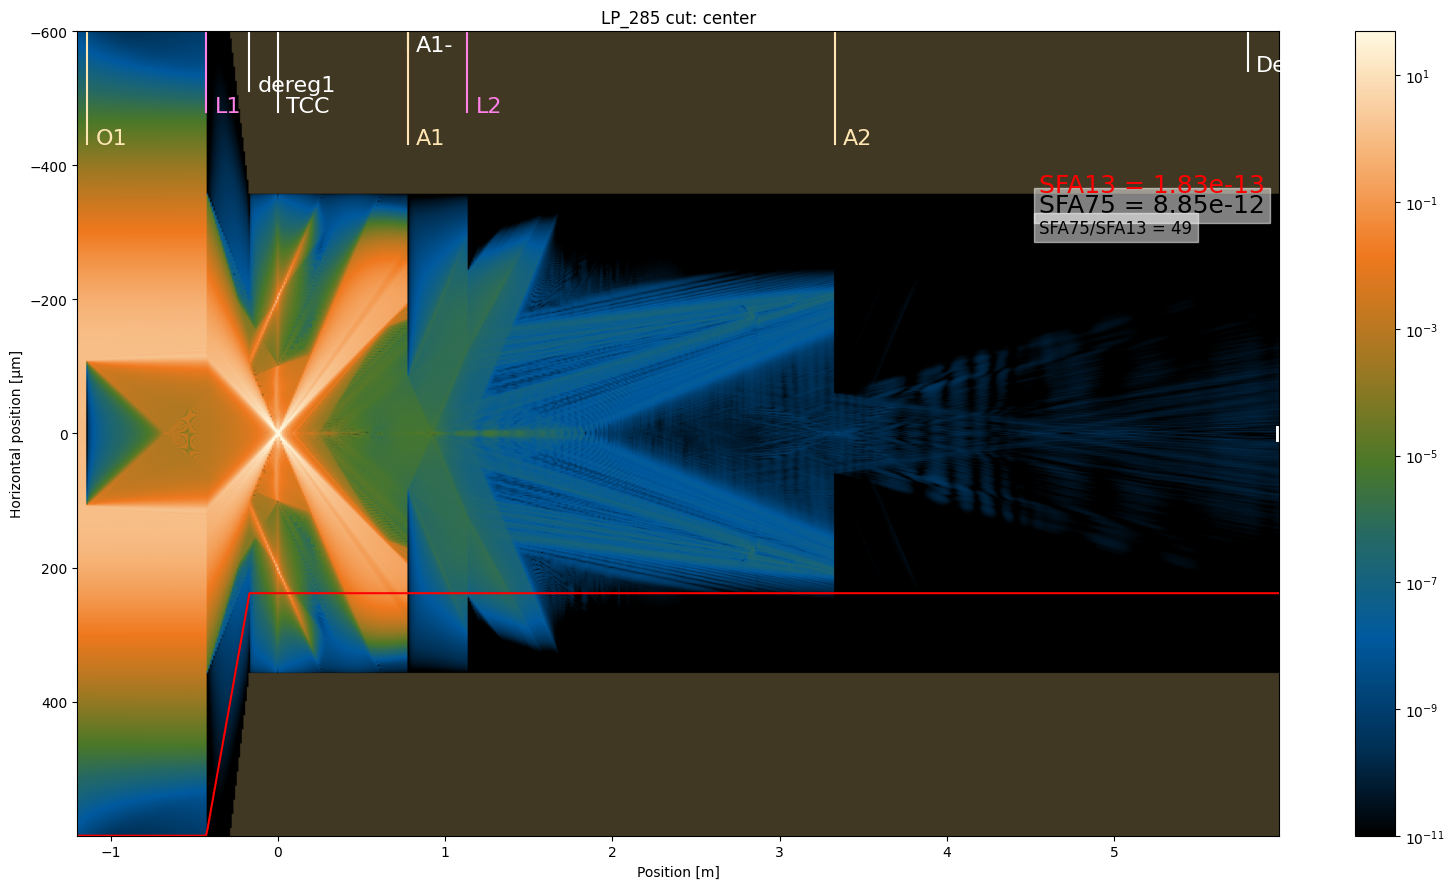

<Figure size 1000x600 with 0 Axes>

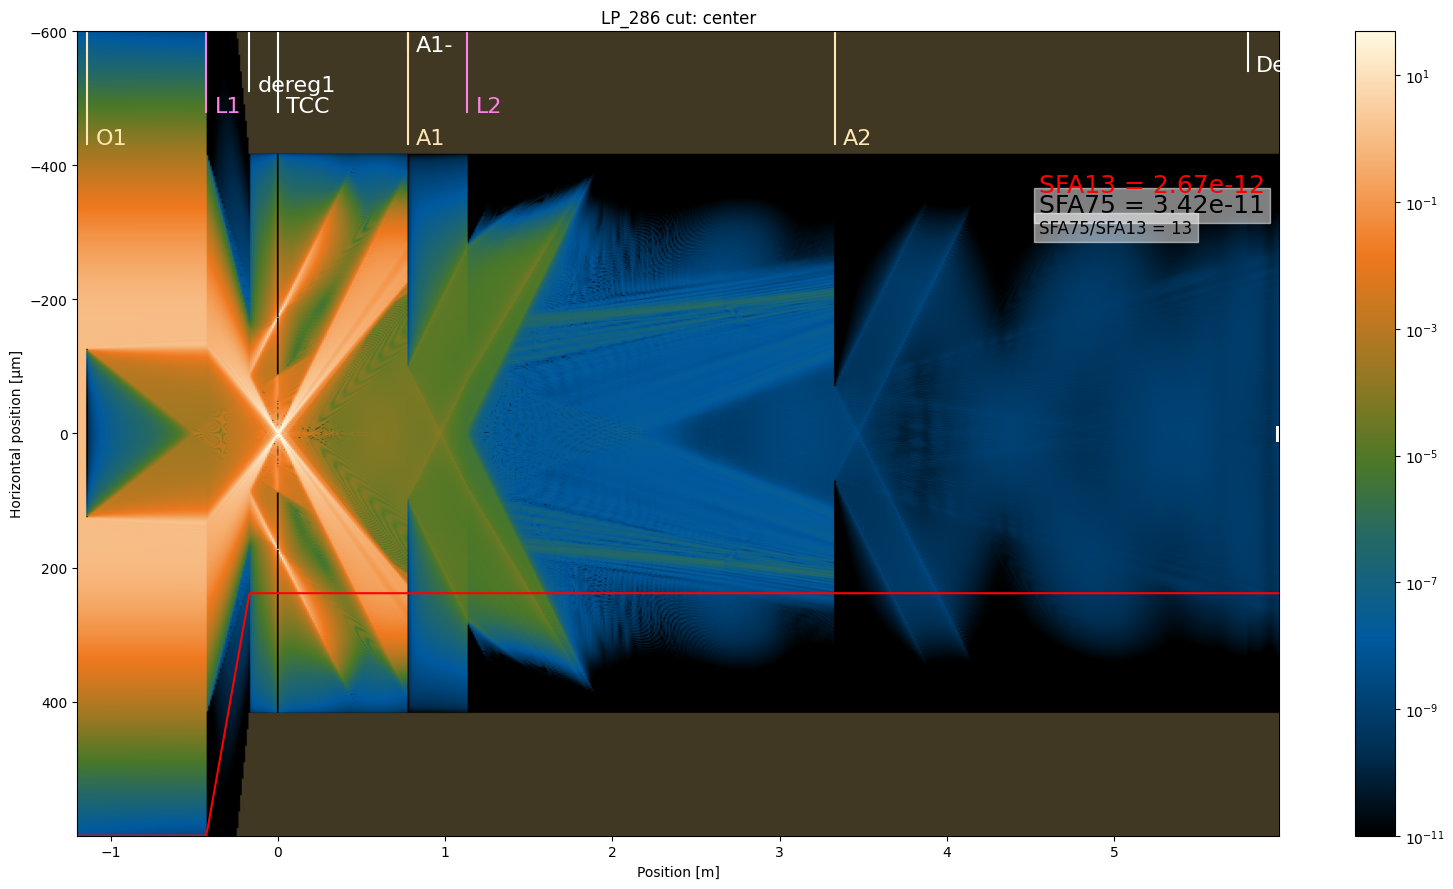

In [7]:
##################### LOOP OF FLOW PLOT OF SIMULATIONS ####################
###################################################################

import importlib
import darkfield.diffra_v2
importlib.reload(darkfield.diffra_v2)
from darkfield.diffra_v2 import flow_plot

import os

# Set working directory
os.chdir("/home/yu79deg")

project_dir = "darkfield_p5438/Aime"

############# LOOP CONTROL ############
LP_start = 278
LP_end = 286  # inclusive
#######################################

############# PLOTTING PARAMETERS ############
cl = [1e-11, 50]                      # Color scale (min, max) for pcolor()
gyax_def = [-600, 600, 0.1]         # vertical axis [start, end, stepsize] in µm
vertical_type = 'center'             # ('center', 'integral', 'vert-integral')
log = 1                              # log scale (linear doesn't work)
xl = None                            # horizontal axis limits (None = auto)
flow_plot_crange = 1e-5              # relative scale for plotting images
flow_figs = 0                        # save flow figs (0 = don't, 1 = yes)
create_video_ff = 0                  # make video from flow figs (requires ffmpeg)

# ========== LOOP THROUGH SIMULATIONS ========== #
for LP_num in range(LP_start, LP_end + 1):
    file = f"LP_{LP_num}"
    print(f"\n========== Processing {file} ==========\n")

    try:
        flow_plot(project_dir, file, cl=cl, gyax_def=gyax_def,
                  vertical_type=vertical_type, log=log, xl=xl,
                  flow_figs=flow_figs, flow_plot_crange=flow_plot_crange)
    except Exception as e:
        print(f"⚠️ Error processing {file}: {e}")
        continue

    # Create video from saved figures
    if create_video_ff and flow_figs:
        image_dir = os.path.join(project_dir, "flow_figs", file)
        output_file = os.path.join(image_dir, "movie.mp4")
        input_pattern = os.path.join(image_dir, "ff_%04d.png")

        cmd = f"ffmpeg -framerate 10 -i {input_pattern} -c:v libx264 -pix_fmt yuv420p {output_file}"
        print(f"Creating video: {output_file}")
        os.system(cmd)


In [32]:

!python /home/yu79deg/darkfield_p5438/notebooks/CRL_calculator/crl_calculator_6.py

qt.qpa.xcb: could not connect to display 
qt.qpa.plugin: Could not load the Qt platform plugin "xcb" in "" even though it was found.
This application failed to start because no Qt platform plugin could be initialized. Reinstalling the application may fix this problem.

Available platform plugins are: eglfs, linuxfb, minimal, minimalegl, offscreen, vnc, wayland-egl, wayland, wayland-xcomposite-egl, wayland-xcomposite-glx, webgl, xcb.



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 MB 96.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [PyQt5]32m2/3 [PyQt5]
